# Análise de Estacionariedade — iRacing Telemetry
## Testes ADF & KPSS para Todos os Pilotos e Pistas

**Objetivo:** Carregar as variáveis principais de todos os pilotos em todas as pistas, consolidar em um único DataFrame e executar os testes de Augmented Dickey-Fuller (ADF) e KPSS para cada série temporal discreta (por volta).

| Hipótese | ADF | KPSS |
|---|---|---|
| H₀ | Raiz unitária (não-estacionário) | Série estacionária |
| Rejeitar H₀ se | p < 0,05 → **estacionário** | p < 0,05 → **não-estacionário** |


In [41]:
import os, sys, warnings, importlib
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import entropy as shannon_entropy

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*kpss.*")

# irsdk (leitura de .ibt)
try:
    import irsdk
    IRSDK_AVAILABLE = True
except ImportError:
    IRSDK_AVAILABLE = False
    print("[WARN] irsdk não encontrado — certifique-se de instalá-lo: pip install irsdk")

print(f"irsdk disponível: {IRSDK_AVAILABLE}")


irsdk disponível: True


## 1. Configuração dos Datasets

In [42]:
PROJECT_ROOT       = Path.home() / "OneDrive/Documents/GitHub/Doutorado/Racing4all"
CONFIG_TRACKS_PATH = PROJECT_ROOT / "Iracing/config_tracks"

if str(CONFIG_TRACKS_PATH) not in sys.path:
    sys.path.append(str(CONFIG_TRACKS_PATH))

# Anonymization map
DRIVER_ALIAS = {
    "Rodrigo":    "Driver A",
    "Tomaz":      "Driver B",
    "Morsinaldo": "Driver C",
}

DATASETS = {
    "charlotte_roval_2025": {
        "base_path": "G:/Meu Drive/Estudos/Datasets - Simracing/Mazda - Charlotte/",
        "car": "Mazda MX-5",
        "sessions": {
            "Tomaz": {
                "stint_1": "mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt"
            },
            "Morsinaldo": {
                "stint_1": "mx5 mx52016_charlotte 2025 roval2025 2026-01-27 16-13-55(Morsinaldo).ibt",
                "stint_2": "mx5 mx52016_charlotte 2025 roval2025 2026-01-28 15-24-41(Morsinaldo).ibt",
            },
            "Rodrigo": {
                "stint_2": "mx5 mx52016_charlotte 2025 roval2025 2026-02-08 15-06-22(Rodrigo).ibt",
            },
        },
    },
    "summit_point": {
        "base_path": "G:/Meu Drive/Estudos/Datasets - Simracing/Toyota GR86 - Summit Point/",
        "car": "Toyota GR86",
        "sessions": {
            "Tomaz": {
                "stint_1": "toyotagr86_summit summit raceway 2026-01-27 22-21-35.ibt"
            },
            "Morsinaldo": {
                "stint_1": "toyotagr86_summit summit raceway 2026-01-28 16-03-13(Morsinaldo).ibt",
                "stint_2": "toyotagr86_summit summit raceway 2026-01-30 08-56-59(Morsinaldo).ibt",
            },
        },
    },
}

TRACK_CONFIG_MAP = {
    "charlotte_roval_2025": "config_roval_2025",
    "summit_point":         "config_summit_point",
}

IBT_CHANNELS = [
    "Lat", "Lon",
    "SessionTime", "Lap", "LapDistPct",
    "Throttle", "ThrottleRaw", "Brake", "BrakeRaw",
    "SteeringWheelAngle",
    "Speed", "LatAccel", "LongAccel", "YawRate",
    "RPM", "Gear", "BrakeABSactive",
]

print("Datasets configured:", list(DATASETS.keys()))
print("Driver aliases:", DRIVER_ALIAS)

Datasets configured: ['charlotte_roval_2025', 'summit_point']
Driver aliases: {'Rodrigo': 'Driver A', 'Tomaz': 'Driver B', 'Morsinaldo': 'Driver C'}


## 2. Funções de Carga e Limpeza

In [43]:
def load_from_ibt(ibt_path: Path) -> pd.DataFrame:
    if not IRSDK_AVAILABLE:
        raise RuntimeError("irsdk not available.")
    if not ibt_path.exists():
        raise FileNotFoundError(f"File not found: {ibt_path}")
    ibt = irsdk.IBT()
    try:
        ibt.open(str(ibt_path))
        data = {ch: ibt.get_all(ch) for ch in IBT_CHANNELS}
    finally:
        ibt.close()
    return pd.DataFrame(data)


def basic_clean_and_units(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.dropna(subset=["SessionTime", "Lap", "LapDistPct"], inplace=True)
    df.sort_values(["Lap", "SessionTime"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    if "Speed" in df.columns:
        df["Speed_KPH"] = df["Speed"] * 3.6

    for col_raw, col_pct in [("Throttle", "Throttle_Pct"), ("Brake", "Brake_Pct")]:
        if col_raw in df.columns:
            df[col_pct] = df[col_raw] * 100.0

    g = 9.81
    for ax_raw, ax_g in [("LatAccel", "LatAccel_G"), ("LongAccel", "LongAccel_G")]:
        if ax_raw in df.columns:
            df[ax_g] = df[ax_raw] / g

    if "LatAccel_G" in df.columns and "LongAccel_G" in df.columns:
        df["TotalAccel_G"] = np.sqrt(df["LatAccel_G"] ** 2 + df["LongAccel_G"] ** 2)

    if "SteeringWheelAngle" in df.columns:
        df["SteeringAngle_deg"] = np.degrees(df["SteeringWheelAngle"])

    return df


def build_lap_validity_table(
    df: pd.DataFrame,
    manual_invalid: set | None = None,
    low_speed_kph: float = 10.0,
    min_max_speed_kph: float = 60.0,
    min_completed_pct: float = 0.98,
    max_lap_time_s: float = 120.0,
) -> pd.DataFrame:
    manual_invalid = manual_invalid or set()
    rows = []
    for lap, g in df.groupby("Lap", sort=True):
        gs = g.sort_values("SessionTime")
        lap_time = float(gs["SessionTime"].iloc[-1] - gs["SessionTime"].iloc[0])
        rows.append({
            "Lap": int(lap),
            "LapTime_s": lap_time,
            "CompletedPct": float(gs["LapDistPct"].max()),
            "FracLowSpeed": float((gs["Speed_KPH"] < low_speed_kph).mean()),
            "MaxSpeed_kph": float(gs["Speed_KPH"].max()),
        })
    lap_df = pd.DataFrame(rows).sort_values("Lap").reset_index(drop=True)
    valid = (
        (lap_df["CompletedPct"] >= min_completed_pct)
        & (~lap_df["Lap"].isin(manual_invalid))
        & (lap_df["FracLowSpeed"] <= 0.25)
        & (lap_df["MaxSpeed_kph"] >= min_max_speed_kph)
        & (lap_df["LapTime_s"] <= max_lap_time_s)
    )
    lap_df["Valid"] = valid
    if lap_df["Valid"].sum() >= 5:
        q1, q3 = lap_df.loc[lap_df["Valid"], "LapTime_s"].quantile([0.25, 0.75])
        iqr = float(q3 - q1)
        lo = max(0.0, float(q1 - 1.5 * iqr))
        hi = float(q3 + 1.5 * iqr)
        lap_df["Valid"] &= lap_df["LapTime_s"].between(lo, hi)
    return lap_df


def preprocess_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["LocalLapTime"] = df.groupby("Lap")["SessionTime"].transform(lambda x: x - x.min())
    return df

print("Load and cleaning functions defined.")

Load and cleaning functions defined.


## 3. Carregamento de Todos os Pilotos × Pistas

In [44]:
all_records = []
all_dfs     = {}

for track_id, config in DATASETS.items():
    base_path = Path(config["base_path"])
    print(f"\n{'='*60}")
    print(f"Track: {track_id}  |  Car: {config['car']}")
    print(f"{'='*60}")

    for driver, stints in config["sessions"].items():
        alias = DRIVER_ALIAS.get(driver, driver)

        for stint_name, file_name in stints.items():
            full_path = base_path / file_name
            key = (track_id, alias, stint_name)

            if not full_path.exists():
                print(f"  WARNING  File not found: {file_name}")
                continue

            print(f"  Loading {alias} | {stint_name} ...", end=" ")

            df_raw = load_from_ibt(full_path)
            if df_raw.empty:
                print("ERROR — empty DataFrame")
                continue

            df_clean   = basic_clean_and_units(df_raw)
            validity   = build_lap_validity_table(df_clean)
            valid_laps = validity.loc[validity["Valid"], "Lap"].tolist()

            if not valid_laps:
                print("ERROR — no valid laps")
                continue

            df_valid = df_clean[df_clean["Lap"].isin(valid_laps)].copy()
            df_valid = preprocess_df(df_valid)

            lap_grp      = df_valid.groupby("Lap")
            lap_times    = lap_grp["SessionTime"].apply(lambda x: x.max() - x.min())
            lap_mean_g   = lap_grp["TotalAccel_G"].mean()
            lap_std_g    = lap_grp["TotalAccel_G"].std()
            lap_max_g    = lap_grp["TotalAccel_G"].max()
            lap_mean_spd = lap_grp["Speed_KPH"].mean()
            lap_mean_thr = lap_grp["Throttle_Pct"].mean()
            lap_mean_brk = lap_grp["Brake_Pct"].mean()

            n_valid = len(valid_laps)
            print(f"OK  {n_valid} valid laps | "
                  f"Best: {lap_times.min():.3f}s | "
                  f"Avg: {lap_times.mean():.3f}s")

            all_dfs[key] = df_valid

            all_records.append({
                "Track":             track_id,
                "Car":               config["car"],
                "Driver":            alias,
                "Stint":             stint_name,
                "N_Valid_Laps":      n_valid,
                "Best_Lap_s":        round(lap_times.min(), 3),
                "Avg_Lap_s":         round(lap_times.mean(), 3),
                "Std_Lap_s":         round(lap_times.std(), 3),
                "Avg_TotalG":        round(lap_mean_g.mean(), 4),
                "Avg_Std_G":         round(lap_std_g.mean(), 4),
                "Avg_Max_G":         round(lap_max_g.mean(), 4),
                "Avg_Speed_KPH":     round(lap_mean_spd.mean(), 2),
                "Avg_Throttle_Pct":  round(lap_mean_thr.mean(), 2),
                "Avg_Brake_Pct":     round(lap_mean_brk.mean(), 2),
            })

df_summary = pd.DataFrame(all_records)
print(f"\n{'='*60}")
print(f"Total stints loaded: {len(all_dfs)}")
display(df_summary)


Track: charlotte_roval_2025  |  Car: Mazda MX-5
  Loading Driver B | stint_1 ... OK  25 valid laps | Best: 96.733s | Avg: 97.875s
  Loading Driver C | stint_1 ... OK  18 valid laps | Best: 99.000s | Avg: 106.435s
  Loading Driver C | stint_2 ... OK  15 valid laps | Best: 98.417s | Avg: 105.916s
  Loading Driver A | stint_2 ... OK  36 valid laps | Best: 95.483s | Avg: 97.567s

Track: summit_point  |  Car: Toyota GR86
  Loading Driver B | stint_1 ... OK  9 valid laps | Best: 79.767s | Avg: 80.256s
  Loading Driver C | stint_1 ... OK  4 valid laps | Best: 82.500s | Avg: 83.392s
  Loading Driver C | stint_2 ... OK  21 valid laps | Best: 80.950s | Avg: 82.813s

Total stints loaded: 7


,Track,Car,Driver,Stint,N_Valid_Laps,Best_Lap_s,Avg_Lap_s,Std_Lap_s,Avg_TotalG,Avg_Std_G,Avg_Max_G,Avg_Speed_KPH,Avg_Throttle_Pct,Avg_Brake_Pct
0,charlotte_roval_2025,Mazda MX-5,Driver B,stint_1,25,96.733,97.875,0.671,0.7646,0.4420,2.8789,132.74,74.67,5.32
1,charlotte_roval_2025,Mazda MX-5,Driver C,stint_1,18,99.000,106.435,8.294,0.7507,0.5007,10.7103,124.01,70.77,5.08
2,charlotte_roval_2025,Mazda MX-5,Driver C,stint_2,15,98.417,105.916,7.483,0.7459,0.5219,12.6988,123.41,71.67,5.25
3,charlotte_roval_2025,Mazda MX-5,Driver A,stint_2,36,95.483,97.567,2.281,0.7725,0.4616,4.3161,133.62,74.36,4.45
4,summit_point,Toyota GR86,Driver B,stint_1,9,79.767,80.256,0.276,0.7589,0.5435,2.6459,143.35,78.57,6.33
5,summit_point,Toyota GR86,Driver C,stint_1,4,82.500,83.392,0.642,0.7161,0.5086,2.3667,137.97,72.13,6.16
6,summit_point,Toyota GR86,Driver C,stint_2,21,80.950,82.813,1.465,0.7410,0.5224,2.3256,139.25,74.31,5.93


## 4. DataFrame de Séries Temporais Discretas (Por Volta)

In [45]:
VARIABLES = {
    "LapTime_s":          "Lap Time (s)",
    "Mean_TotalG":        "Mean Total G-Force (G)",
    "Std_TotalG":         "Std Dev Total G-Force (G)",
    "Mean_Speed_KPH":     "Mean Speed (km/h)",
    "Mean_Throttle_Pct":  "Mean Throttle (%)",
    "Mean_Brake_Pct":     "Mean Brake (%)",
}

lap_rows = []

for (track_id, alias, stint_name), df in all_dfs.items():
    grp      = df.groupby("Lap")
    lap_time = grp["SessionTime"].apply(lambda x: x.max() - x.min())
    mean_g   = grp["TotalAccel_G"].mean()
    std_g    = grp["TotalAccel_G"].std()
    max_g    = grp["TotalAccel_G"].quantile(0.99)
    mean_spd = grp["Speed_KPH"].mean()
    mean_thr = grp["Throttle_Pct"].mean()
    mean_brk = grp["Brake_Pct"].mean()

    for lap in lap_time.index:
        lap_rows.append({
            "Track":             track_id,
            "Driver":            alias,
            "Stint":             stint_name,
            "Lap":               lap,
            "LapTime_s":         lap_time[lap],
            "Mean_TotalG":       mean_g[lap],
            "Std_TotalG":        std_g[lap],
            "Max_TotalG":        max_g[lap],
            "Mean_Speed_KPH":    mean_spd[lap],
            "Mean_Throttle_Pct": mean_thr[lap],
            "Mean_Brake_Pct":    mean_brk[lap],
        })

df_laps = pd.DataFrame(lap_rows).reset_index(drop=True)
df_laps["Session"] = df_laps["Driver"] + " | " + df_laps["Track"] + " | " + df_laps["Stint"]

print(f"Shape: {df_laps.shape}")
print(f"\nUnique sessions ({df_laps['Session'].nunique()}):")
for s in sorted(df_laps["Session"].unique()):
    n = df_laps[df_laps["Session"] == s].shape[0]
    print(f"  {s}  →  {n} laps")
display(df_laps.head(10))

Shape: (128, 12)

Unique sessions (7):
  Driver A | charlotte_roval_2025 | stint_2  →  36 laps
  Driver B | charlotte_roval_2025 | stint_1  →  25 laps
  Driver B | summit_point | stint_1  →  9 laps
  Driver C | charlotte_roval_2025 | stint_1  →  18 laps
  Driver C | charlotte_roval_2025 | stint_2  →  15 laps
  Driver C | summit_point | stint_1  →  4 laps
  Driver C | summit_point | stint_2  →  21 laps


,Track,Driver,Stint,Lap,LapTime_s,Mean_TotalG,Std_TotalG,Max_TotalG,Mean_Speed_KPH,Mean_Throttle_Pct,Mean_Brake_Pct,Session
0,charlotte_roval_2025,Driver B,stint_1,1,98.266667,0.752324,0.448738,1.846669,131.999343,73.873090,5.650420,Driver B | charlotte_roval_2025 | stint_1
1,charlotte_roval_2025,Driver B,stint_1,2,99.416667,0.746515,0.459740,1.891737,130.531359,73.497462,5.571182,Driver B | charlotte_roval_2025 | stint_1
2,charlotte_roval_2025,Driver B,stint_1,3,98.083333,0.752680,0.451484,1.877362,132.177713,74.728227,5.501877,Driver B | charlotte_roval_2025 | stint_1
3,charlotte_roval_2025,Driver B,stint_1,4,97.283333,0.758142,0.448484,1.864357,133.400204,75.679277,5.515014,Driver B | charlotte_roval_2025 | stint_1
4,charlotte_roval_2025,Driver B,stint_1,6,97.933333,0.761981,0.433878,1.784969,132.509575,76.347726,5.938081,Driver B | charlotte_roval_2025 | stint_1
5,charlotte_roval_2025,Driver B,stint_1,7,97.283333,0.758907,0.453709,1.867417,133.247536,75.970005,5.740709,Driver B | charlotte_roval_2025 | stint_1
6,charlotte_roval_2025,Driver B,stint_1,8,99.066667,0.759301,0.444388,1.793094,131.603523,75.105636,6.100007,Driver B | charlotte_roval_2025 | stint_1
7,charlotte_roval_2025,Driver B,stint_1,9,98.400000,0.772128,0.435163,1.772182,132.081311,73.182803,5.017175,Driver B | charlotte_roval_2025 | stint_1
8,charlotte_roval_2025,Driver B,stint_1,11,97.866667,0.759191,0.448345,1.812639,132.787236,75.233283,5.907452,Driver B | charlotte_roval_2025 | stint_1
9,charlotte_roval_2025,Driver B,stint_1,12,97.866667,0.766636,0.447281,1.771389,133.124901,74.790119,5.381577,Driver B | charlotte_roval_2025 | stint_1


## 5. Visualização Exploratória das Séries

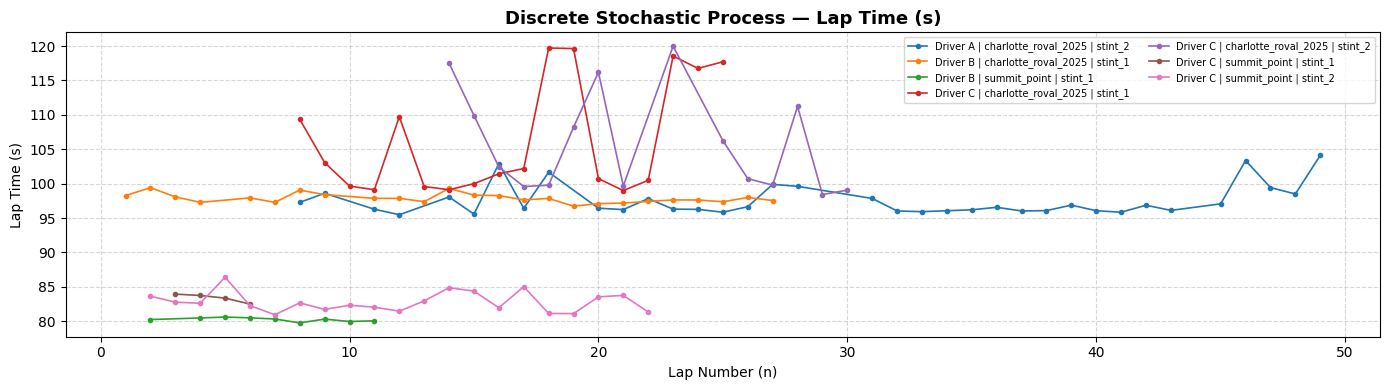

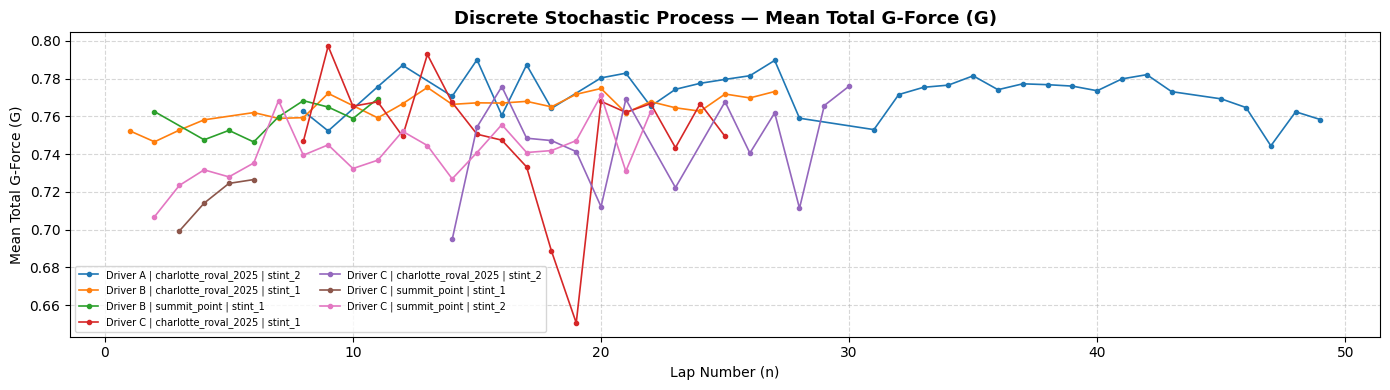

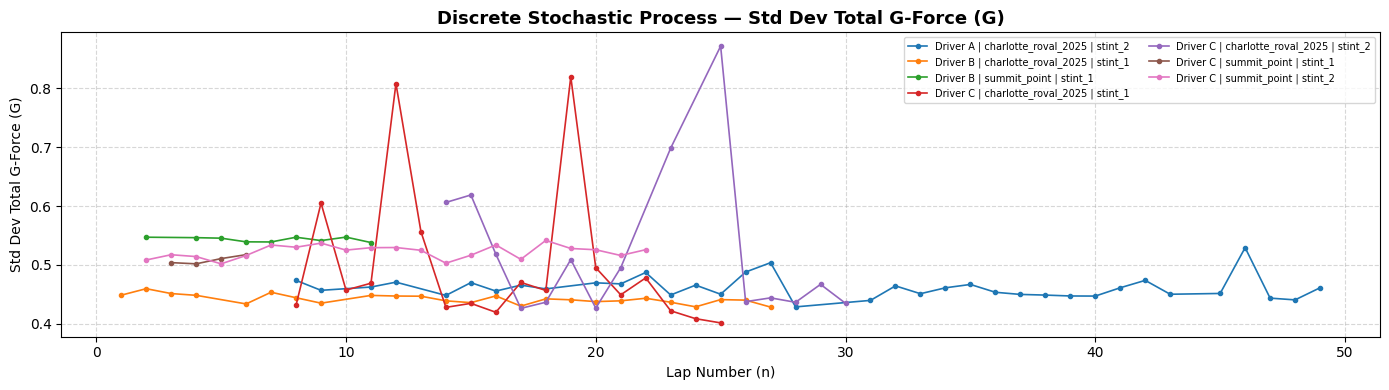

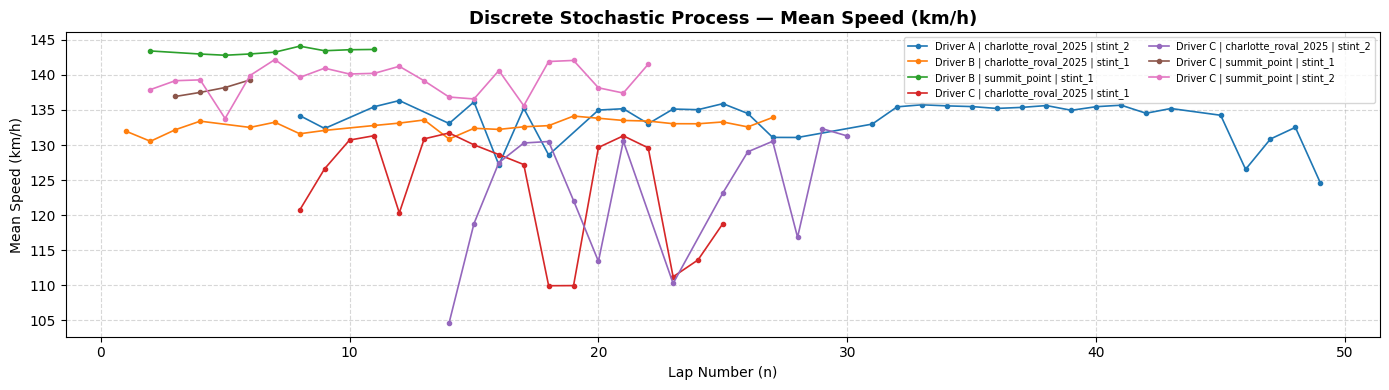

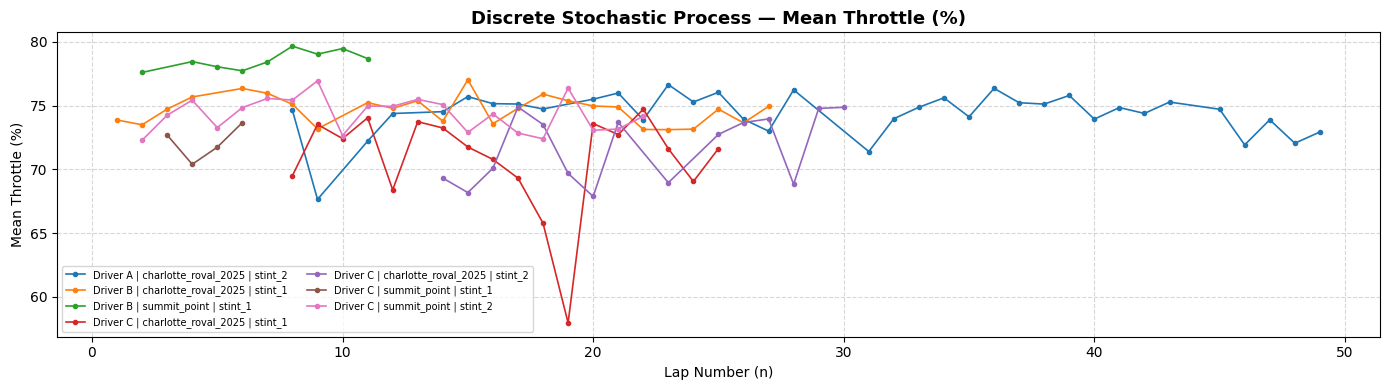

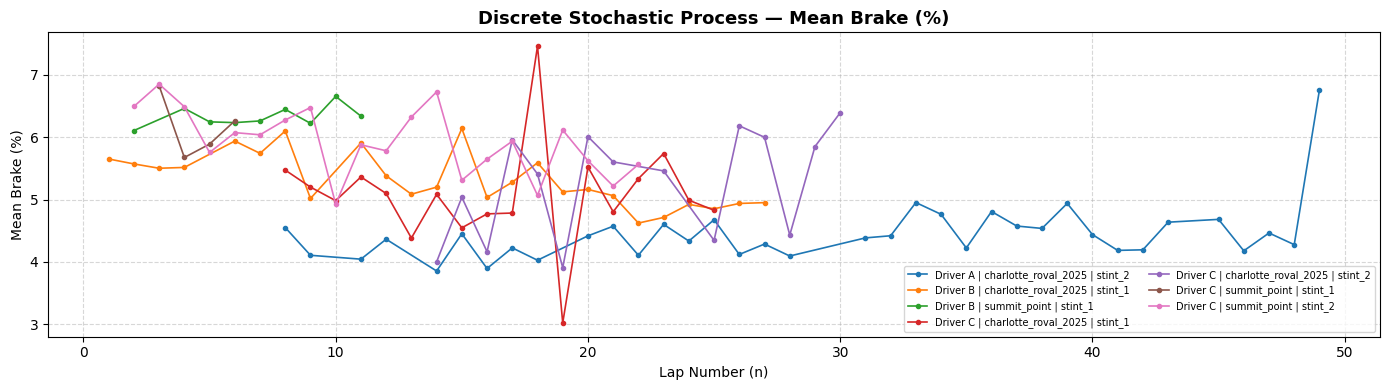

In [46]:
sessions  = sorted(df_laps["Session"].unique())
palette   = sns.color_palette("tab10", n_colors=len(sessions))
color_map = dict(zip(sessions, palette))

for var, label in VARIABLES.items():
    fig, ax = plt.subplots(figsize=(14, 4))
    for sess in sessions:
        sub = df_laps[df_laps["Session"] == sess].sort_values("Lap")
        ax.plot(sub["Lap"], sub[var], marker="o", markersize=3,
                linewidth=1.2, label=sess, color=color_map[sess])
    ax.set_title(f"Discrete Stochastic Process — {label}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Lap Number (n)")
    ax.set_ylabel(label)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

## 6. Testes de Estacionariedade (ADF & KPSS)

In [47]:
def run_adf(series: pd.Series, regression: str = "ct") -> dict:
    """
    Augmented Dickey-Fuller.
    H0: unit root (non-stationary).
    Reject H0 (p < 0.05) -> STATIONARY.
    """
    series = series.dropna()
    if len(series) < 8:
        return {"stat": np.nan, "p": np.nan, "lags": np.nan,
                "crit_1pct": np.nan, "stationary": None}
    res = adfuller(series, autolag="AIC", regression=regression)
    return {
        "stat":       round(res[0], 4),
        "p":          round(res[1], 6),
        "lags":       res[2],
        "crit_1pct":  round(res[4]["1%"], 4),
        "stationary": bool(res[1] < 0.05),
    }


def run_kpss(series: pd.Series, regression: str = "ct") -> dict:
    """
    KPSS.
    H0: series is stationary.
    Reject H0 (p < 0.05) -> NON-STATIONARY.
    """
    series = series.dropna()
    if len(series) < 8:
        return {"stat": np.nan, "p": np.nan, "lags": np.nan,
                "crit_5pct": np.nan, "stationary": None}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, p, lags, crit = kpss(series, regression=regression, nlags="auto")
    return {
        "stat":       round(stat, 4),
        "p":          round(p, 6),
        "lags":       lags,
        "crit_5pct":  round(crit["5%"], 4),
        "stationary": bool(p >= 0.05),
    }


def stationarity_verdict(adf_stat, kpss_stat) -> str:
    if adf_stat is None or kpss_stat is None:
        return "N/A"
    if adf_stat and kpss_stat:
        return "Stationary"
    if not adf_stat and not kpss_stat:
        return "Non-Stationary"
    if adf_stat and not kpss_stat:
        return "Difference-Stationary"
    return "Trend-Stationary"

print("ADF and KPSS functions defined.")

ADF and KPSS functions defined.


In [48]:
REGRESSION = "ct"  # 'c' = constant only | 'ct' = constant + trend | 'nc' = none

test_results = []

for sess in sorted(df_laps["Session"].unique()):
    sub = df_laps[df_laps["Session"] == sess].sort_values("Lap")
    parts = sess.split(" | ")
    driver, track, stint = parts[0], parts[1], parts[2]

    for var, label in VARIABLES.items():
        series = sub[var].reset_index(drop=True)

        adf   = run_adf(series,  regression=REGRESSION)
        kpss_ = run_kpss(series, regression=REGRESSION)

        test_results.append({
            "Session":         sess,
            "Driver":          driver,
            "Track":           track,
            "Stint":           stint,
            "Variable":        var,
            "Label":           label,
            "N_Laps":          len(series),
            "ADF_Statistic":   adf["stat"],
            "ADF_p_value":     adf["p"],
            "ADF_Lags":        adf["lags"],
            "ADF_Crit_1pct":   adf["crit_1pct"],
            "ADF_Stationary":  adf["stationary"],
            "KPSS_Statistic":  kpss_["stat"],
            "KPSS_p_value":    kpss_["p"],
            "KPSS_Lags":       kpss_["lags"],
            "KPSS_Crit_5pct":  kpss_["crit_5pct"],
            "KPSS_Stationary": kpss_["stationary"],
            "Verdict":         stationarity_verdict(adf["stationary"], kpss_["stationary"]),
        })

df_results = pd.DataFrame(test_results)
print(f"{len(df_results)} tests completed  "
      f"({df_laps['Session'].nunique()} sessions × {len(VARIABLES)} variables)")
display(df_results.head(12))

42 tests completed  (7 sessions × 6 variables)


,Session,Driver,Track,Stint,Variable,Label,N_Laps,ADF_Statistic,ADF_p_value,ADF_Lags,ADF_Crit_1pct,ADF_Stationary,KPSS_Statistic,KPSS_p_value,KPSS_Lags,KPSS_Crit_5pct,KPSS_Stationary,Verdict
0,Driver A | charlotte_roval_2025 | stint_2,Driver A,charlotte_roval_2025,stint_2,LapTime_s,Lap Time (s),36,-1.5216,0.821611,2.0,-4.2629,False,0.1304,0.078922,3.0,0.146,True,Trend-Stationary
1,Driver A | charlotte_roval_2025 | stint_2,Driver A,charlotte_roval_2025,stint_2,Mean_TotalG,Mean Total G-Force (G),36,-4.8979,0.000314,0.0,-4.2438,True,0.1100,0.100000,2.0,0.146,True,Stationary
2,Driver A | charlotte_roval_2025 | stint_2,Driver A,charlotte_roval_2025,stint_2,Std_TotalG,Std Dev Total G-Force (G),36,-5.6727,0.000010,1.0,-4.2530,True,0.2303,0.010000,15.0,0.146,False,Difference-Stationary
3,Driver A | charlotte_roval_2025 | stint_2,Driver A,charlotte_roval_2025,stint_2,Mean_Speed_KPH,Mean Speed (km/h),36,-1.2783,0.893191,2.0,-4.2629,False,0.1334,0.073413,3.0,0.146,True,Trend-Stationary
4,Driver A | charlotte_roval_2025 | stint_2,Driver A,charlotte_roval_2025,stint_2,Mean_Throttle_Pct,Mean Throttle (%),36,-4.6280,0.000925,0.0,-4.2438,True,0.1403,0.060476,2.0,0.146,True,Stationary
5,Driver A | charlotte_roval_2025 | stint_2,Driver A,charlotte_roval_2025,stint_2,Mean_Brake_Pct,Mean Brake (%),36,-3.9444,0.010532,7.0,-4.3245,True,0.0547,0.100000,1.0,0.146,True,Stationary
6,Driver B | charlotte_roval_2025 | stint_1,Driver B,charlotte_roval_2025,stint_1,LapTime_s,Lap Time (s),25,-4.2446,0.003830,0.0,-4.3950,True,0.0642,0.100000,0.0,0.146,True,Stationary
7,Driver B | charlotte_roval_2025 | stint_1,Driver B,charlotte_roval_2025,stint_1,Mean_TotalG,Mean Total G-Force (G),25,-6.1061,0.000001,6.0,-4.5725,True,0.1791,0.023856,2.0,0.146,False,Difference-Stationary
8,Driver B | charlotte_roval_2025 | stint_1,Driver B,charlotte_roval_2025,stint_1,Std_TotalG,Std Dev Total G-Force (G),25,0.0820,0.994975,9.0,-4.7284,False,0.5000,0.010000,24.0,0.146,False,Non-Stationary
9,Driver B | charlotte_roval_2025 | stint_1,Driver B,charlotte_roval_2025,stint_1,Mean_Speed_KPH,Mean Speed (km/h),25,-4.2823,0.003352,0.0,-4.3950,True,0.0479,0.100000,1.0,0.146,True,Stationary


## 7. Tabela Resumo — Vereditos por Sessão × Variável

In [49]:
pivot_verdict = df_results.pivot_table(
    index=["Driver", "Track", "Stint"],
    columns="Variable",
    values="Verdict",
    aggfunc="first",
)
pivot_verdict.columns = [VARIABLES[c].split(" (")[0] for c in pivot_verdict.columns]

print("Legend:")
print("  Stationary            — ADF: reject H0  |  KPSS: do not reject H0")
print("  Non-Stationary        — ADF: do not reject  |  KPSS: reject H0")
print("  Difference-Stationary — ADF: reject  |  KPSS: reject (deterministic trend)")
print("  Trend-Stationary      — ADF: do not reject  |  KPSS: do not reject (weak drift)\n")
display(pivot_verdict)

Legend:
  Stationary            — ADF: reject H0  |  KPSS: do not reject H0
  Non-Stationary        — ADF: do not reject  |  KPSS: reject H0
  Difference-Stationary — ADF: reject  |  KPSS: reject (deterministic trend)
  Trend-Stationary      — ADF: do not reject  |  KPSS: do not reject (weak drift)



Lap Time  \
Driver   Track                Stint                       
Driver A charlotte_roval_2025 stint_2  Trend-Stationary   
Driver B charlotte_roval_2025 stint_1        Stationary   
         summit_point         stint_1  Trend-Stationary   
Driver C charlotte_roval_2025 stint_1  Trend-Stationary   
                              stint_2        Stationary   
         summit_point         stint_1               N/A   
                              stint_2        Stationary   

                                                  Mean Brake  \
Driver   Track                Stint                            
Driver A charlotte_roval_2025 stint_2             Stationary   
Driver B charlotte_roval_2025 stint_1       Trend-Stationary   
         summit_point         stint_1  Difference-Stationary   
Driver C charlotte_roval_2025 stint_1         Non-Stationary   
                              stint_2       Trend-Stationary   
         summit_point         stint_1                    N/A   
                              stint_2       Trend-Stationary   

                                             Mean Speed     Mean Throttle  \
Driver   Track                Stint                                         
Driver A charlotte_roval_2025 stint_2  Trend-Stationary        Stationary   
Driver B charlotte_roval_2025 stint_1        Stationary        Stationary   
         summit_point         stint_1  Trend-Stationary  Trend-Stationary   
Driver C charlotte_roval_2025 stint_1        Stationary  Trend-Stationary   
                              stint_2  Trend-Stationary  Trend-Stationary   
         summit_point         stint_1               N/A               N/A   
                              stint_2        Stationary  Trend-Stationary   

                                          Mean Total G-Force  \
Driver   Track                Stint                            
Driver A charlotte_roval_2025 stint_2             Stationary   
Driver B charlotte_roval_2025 stint_1  Difference-Stationary   
         summit_point         stint_1       Trend-Stationary   
Driver C charlotte_roval_2025 stint_1       Trend-Stationary   
                              stint_2             Stationary   
         summit_point         stint_1                    N/A   
                              stint_2             Stationary   

                                       Std Dev Total G-Force  
Driver   Track                Stint                           
Driver A charlotte_roval_2025 stint_2  Difference-Stationary  
Driver B charlotte_roval_2025 stint_1         Non-Stationary  
         summit_point         stint_1       Trend-Stationary  
Driver C charlotte_roval_2025 stint_1             Stationary  
                              stint_2       Trend-Stationary  
         summit_point         stint_1                    N/A  
                              stint_2             Stationary

## 8. Resultados Numéricos Detalhados

In [50]:
cols_display = [
    "Driver", "Track", "Stint", "Variable", "N_Laps",
    "ADF_Statistic", "ADF_p_value", "ADF_Stationary",
    "KPSS_Statistic", "KPSS_p_value", "KPSS_Stationary",
    "Verdict",
]

df_display = df_results[cols_display].copy()
df_display["ADF_p_value"]  = df_display["ADF_p_value"].map(lambda x: f"{x:.4e}" if pd.notna(x) else "—")
df_display["KPSS_p_value"] = df_display["KPSS_p_value"].map(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
df_display["ADF_Statistic"]  = df_display["ADF_Statistic"].round(4)
df_display["KPSS_Statistic"] = df_display["KPSS_Statistic"].round(4)

def fmt_bool(val):
    if val is True:
        return "Yes"
    if val is False:
        return "No"
    return "—"

df_display["ADF_Stationary"]  = df_display["ADF_Stationary"].map(fmt_bool)
df_display["KPSS_Stationary"] = df_display["KPSS_Stationary"].map(fmt_bool)

display(df_display)

,Driver,Track,Stint,Variable,N_Laps,ADF_Statistic,ADF_p_value,ADF_Stationary,KPSS_Statistic,KPSS_p_value,KPSS_Stationary,Verdict
0,Driver A,charlotte_roval_2025,stint_2,LapTime_s,36,-1.5216,8.2161e-01,No,0.1304,0.0789,Yes,Trend-Stationary
1,Driver A,charlotte_roval_2025,stint_2,Mean_TotalG,36,-4.8979,3.1400e-04,Yes,0.1100,0.1000,Yes,Stationary
2,Driver A,charlotte_roval_2025,stint_2,Std_TotalG,36,-5.6727,1.0000e-05,Yes,0.2303,0.0100,No,Difference-Stationary
3,Driver A,charlotte_roval_2025,stint_2,Mean_Speed_KPH,36,-1.2783,8.9319e-01,No,0.1334,0.0734,Yes,Trend-Stationary
4,Driver A,charlotte_roval_2025,stint_2,Mean_Throttle_Pct,36,-4.6280,9.2500e-04,Yes,0.1403,0.0605,Yes,Stationary
5,Driver A,charlotte_roval_2025,stint_2,Mean_Brake_Pct,36,-3.9444,1.0532e-02,Yes,0.0547,0.1000,Yes,Stationary
6,Driver B,charlotte_roval_2025,stint_1,LapTime_s,25,-4.2446,3.8300e-03,Yes,0.0642,0.1000,Yes,Stationary
7,Driver B,charlotte_roval_2025,stint_1,Mean_TotalG,25,-6.1061,1.0000e-06,Yes,0.1791,0.0239,No,Difference-Stationary
8,Driver B,charlotte_roval_2025,stint_1,Std_TotalG,25,0.0820,9.9498e-01,No,0.5000,0.0100,No,Non-Stationary
9,Driver B,charlotte_roval_2025,stint_1,Mean_Speed_KPH,25,-4.2823,3.3520e-03,Yes,0.0479,0.1000,Yes,Stationary


## 9. Heatmap de p-valores (ADF)

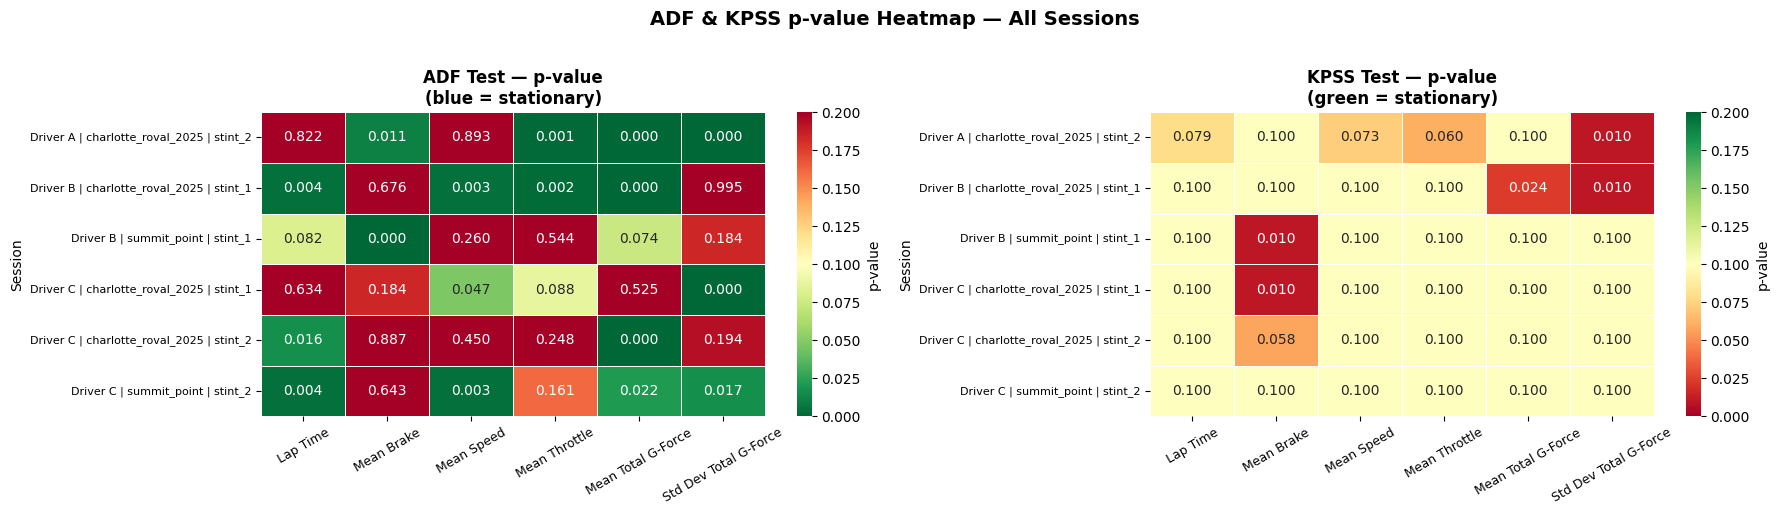

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(18, max(5, len(df_laps["Session"].unique()) * 0.7)))

for ax, test, col_p in zip(axes, ["ADF", "KPSS"], ["ADF_p_value", "KPSS_p_value"]):
    pivot_p = df_results.pivot_table(
        index="Session",
        columns="Variable",
        values=col_p,
        aggfunc="first",
    ).astype(float)

    pivot_p.columns = [VARIABLES[c].split(" (")[0] for c in pivot_p.columns]

    cmap = "RdYlGn_r" if test == "ADF" else "RdYlGn"
    annot_data = pivot_p.applymap(lambda v: f"{v:.3f}" if pd.notna(v) else "—")

    sns.heatmap(
        pivot_p, ax=ax, cmap=cmap, vmin=0, vmax=0.20,
        annot=annot_data, fmt="", linewidths=0.5,
        cbar_kws={"label": "p-value"},
    )
    direction = "blue = stationary" if test == "ADF" else "green = stationary"
    ax.set_title(f"{test} Test — p-value\n({direction})", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Session", fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.suptitle("ADF & KPSS p-value Heatmap — All Sessions",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 10. Séries com Média e Desvio Padrão Móveis (Rolling Statistics)

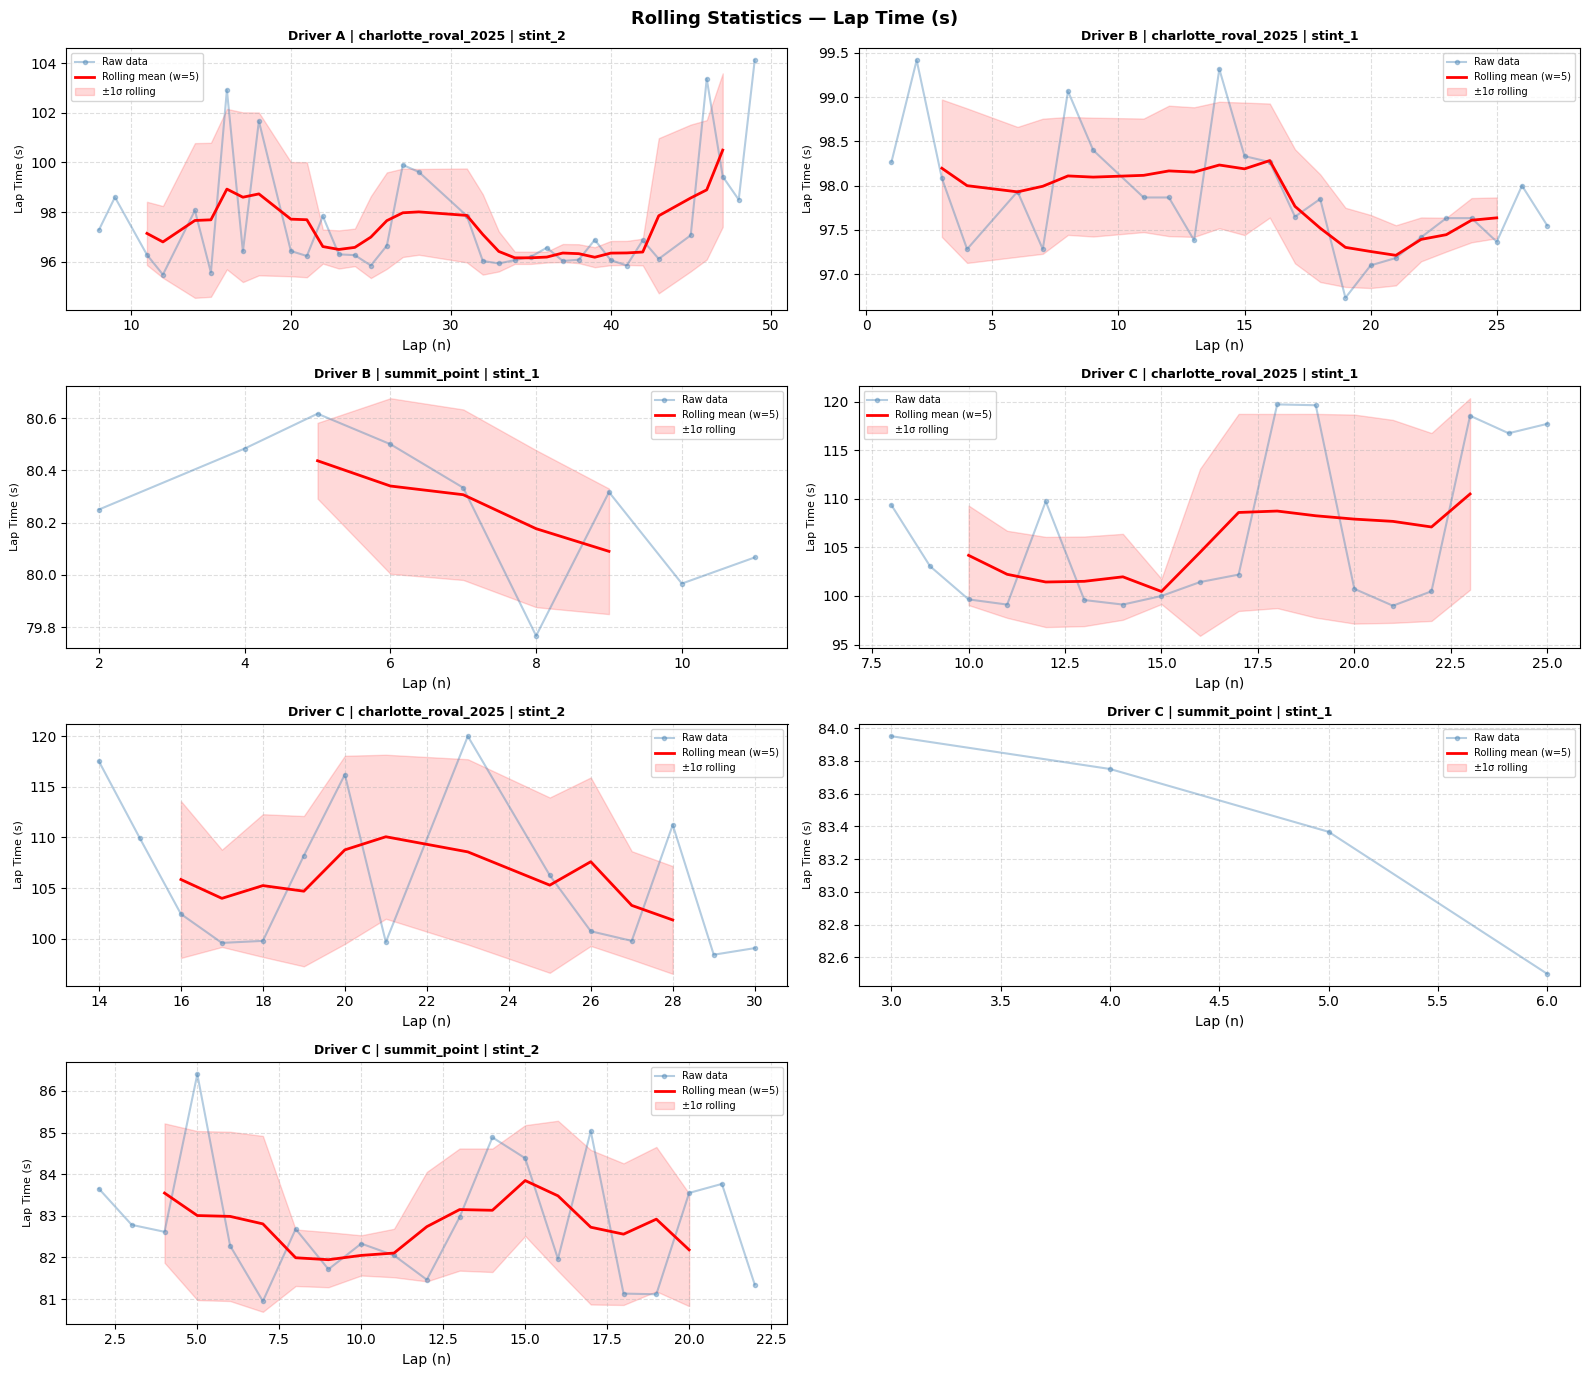

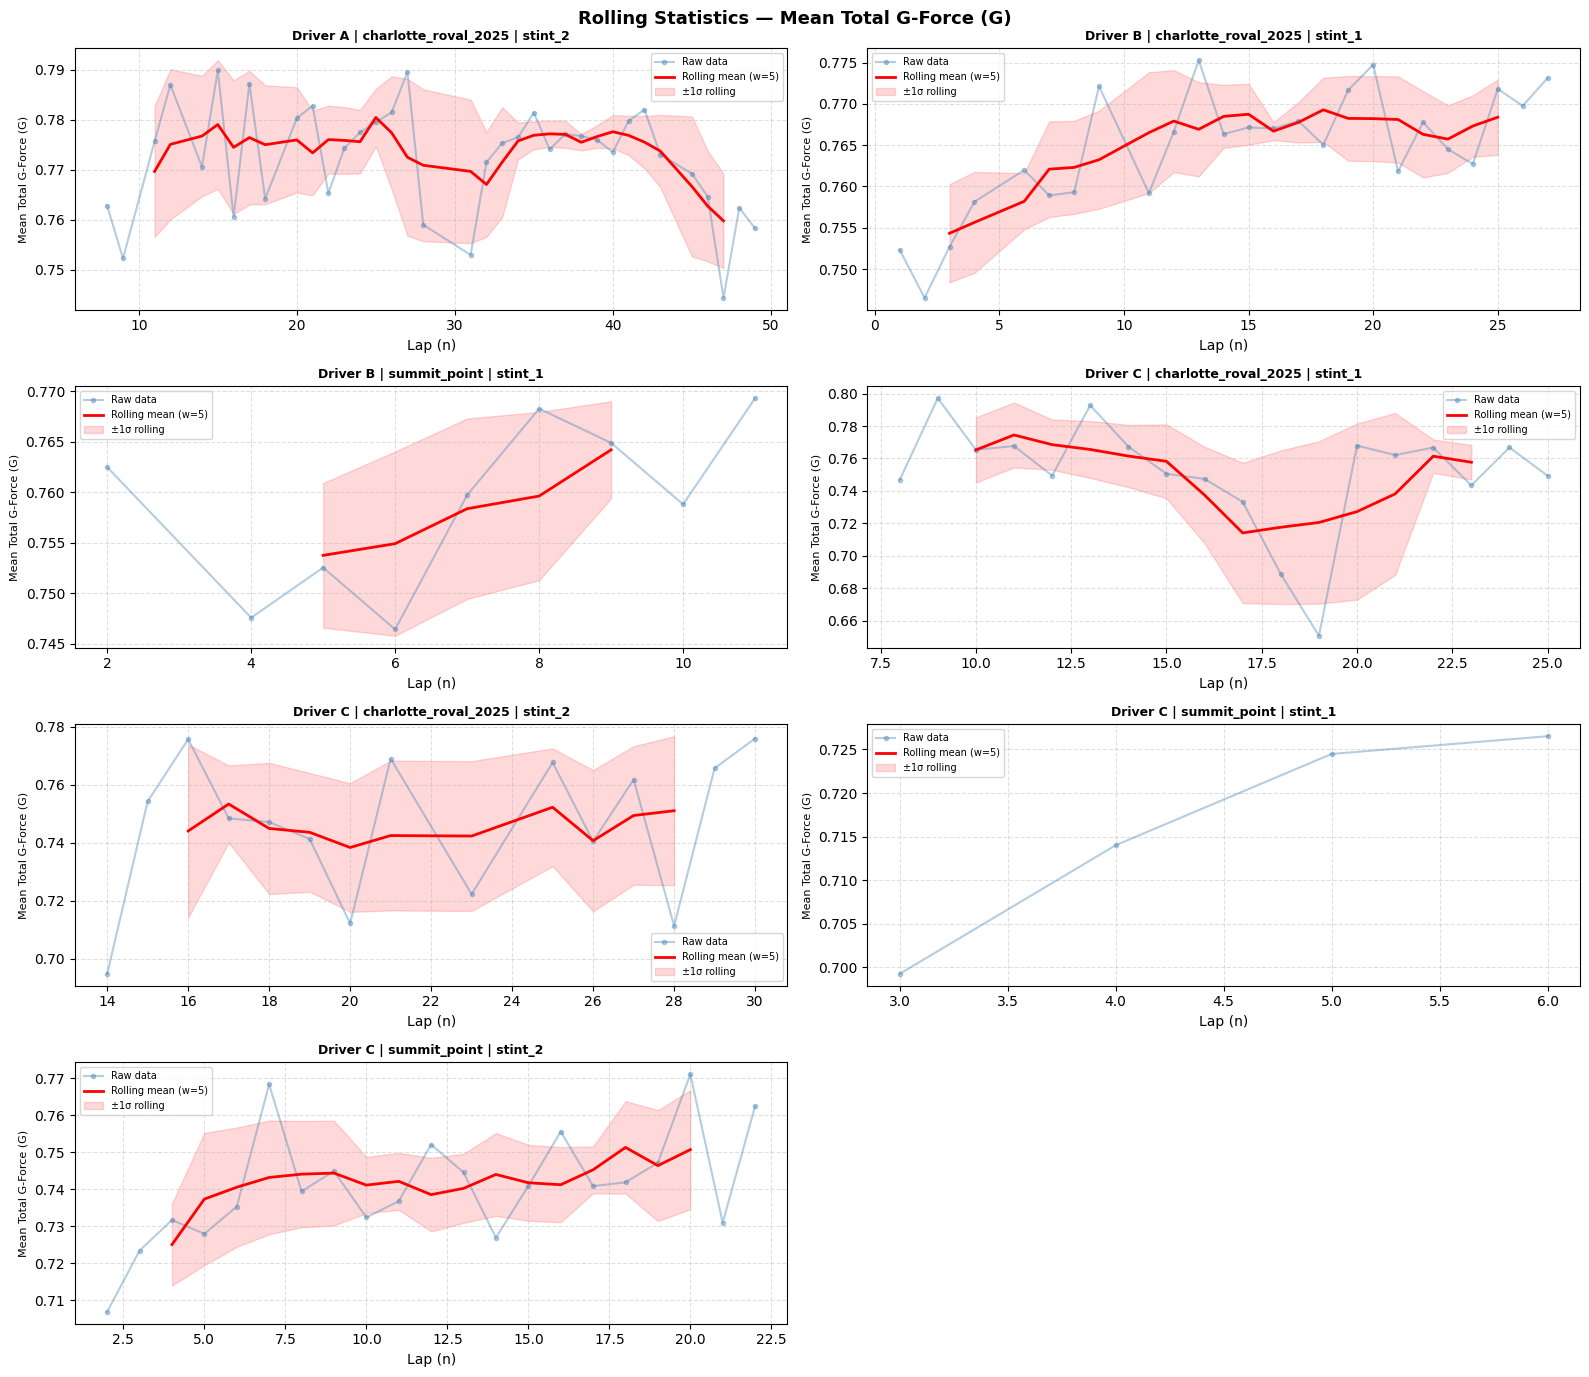

In [52]:
def plot_rolling_stats(df_laps, variable, label, window=5):
    sessions = sorted(df_laps["Session"].unique())
    ncols = 2
    nrows = (len(sessions) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows), sharex=False)
    axes = axes.flatten()

    for i, sess in enumerate(sessions):
        ax = axes[i]
        sub = df_laps[df_laps["Session"] == sess].sort_values("Lap").reset_index(drop=True)
        s = sub[variable]
        rolling_mean = s.rolling(window=window, center=True).mean()
        rolling_std  = s.rolling(window=window, center=True).std()

        ax.plot(sub["Lap"], s, color="steelblue", alpha=0.4,
                marker="o", markersize=3, label="Raw data")
        ax.plot(sub["Lap"], rolling_mean, color="red", linewidth=2,
                label=f"Rolling mean (w={window})")
        ax.fill_between(
            sub["Lap"],
            rolling_mean - rolling_std,
            rolling_mean + rolling_std,
            color="red", alpha=0.15, label="±1σ rolling",
        )
        ax.set_title(sess, fontsize=9, fontweight="bold")
        ax.set_xlabel("Lap (n)")
        ax.set_ylabel(label, fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, linestyle="--", alpha=0.4)

    for j in range(len(sessions), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Rolling Statistics — {label}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_rolling_stats(df_laps, "LapTime_s",   "Lap Time (s)")
plot_rolling_stats(df_laps, "Mean_TotalG", "Mean Total G-Force (G)")

## 11. Exportação dos Resultados

In [53]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Tabela de resultados completos
results_path = OUTPUT_DIR / "adf_kpss_results.csv"
df_results.to_csv(results_path, index=False)
print(f"✅ Resultados exportados → {results_path}")

# Tabela de séries por volta
laps_path = OUTPUT_DIR / "lap_series.csv"
df_laps.to_csv(laps_path, index=False)
print(f"✅ Séries por volta exportadas → {laps_path}")

# Resumo por piloto/pista
summary_path = OUTPUT_DIR / "session_summary.csv"
df_summary.to_csv(summary_path, index=False)
print(f"✅ Resumo de sessões exportado → {summary_path}")


✅ Resultados exportados → outputs\adf_kpss_results.csv
✅ Séries por volta exportadas → outputs\lap_series.csv
✅ Resumo de sessões exportado → outputs\session_summary.csv


## 12. Guia de Interpretação dos Resultados

### Combinação ADF + KPSS

| ADF | KPSS | Interpretação |
|---|---|---|
| p < 0,05 (Rejeita H₀) | p ≥ 0,05 (Não rejeita H₀) | ✅ **Estacionário** — processo estável |
| p ≥ 0,05 (Não rejeita H₀) | p < 0,05 (Rejeita H₀) | ❌ **Não-Estacionário** — raiz unitária presente |
| p < 0,05 | p < 0,05 | ⚠️ **Diferença-Estacionário** — tendência determinística, aplicar 1ª diferença |
| p ≥ 0,05 | p ≥ 0,05 | ⚠️ **Evidência insuficiente** — série curta ou estrutura mista |

### Significado Físico para Sim-Racing

| Variável | Estacionária | Não-Estacionária |
|---|---|---|
| **LapTime_s** | Pace consistente sem fadiga/melhoria sistemática | Fadiga, aprendizado ou degração de pneus |
| **Mean_TotalG** | Carga lateral/longitudinal estável | Mudança de limite físico ao longo do stint |
| **Std_TotalG** | Consistência estável | Aumento/redução de erros ao longo do tempo |
| **Mean_Speed_KPH** | Velocidade de referência constante | Desgaste ou mudança de estratégia |
| **Mean_Throttle_Pct** | Gestão de acelerador consistente | Adaptação à degradação |
| **Mean_Brake_Pct** | Freio consistente | Fadiga ou ajuste de ponto de frenagem |
